# Point source sensitivity calculator

This notebook shows how to compute a point source sensitivity for a specific model. In the current status of cosipy, we are limited by the available responses, i.e at 511, 1157, 1173, 1333 and 1809 keV and a coarse continuum. Keep in mind that due to the coarseness of the current responses, the sensitivity might be underestimated. 

The collaboration is currently developping a neural network approach for the response to use with an unbinned analysis. This will allow us to fully exploit COSI power. 

In [11]:
import os
import logging
import sys



logger = logging.getLogger('cosipy')
logger.setLevel(logging.INFO)
logger.addHandler(logging.StreamHandler(sys.stdout))

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"


from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.util import fetch_wasabi_file

from cosipy.statistics import PoissonLikelihood
from cosipy.background_estimation import FreeNormBinnedBackground
from cosipy.interfaces import ThreeMLPluginInterface
from cosipy.response import BinnedThreeMLModelFolding, BinnedInstrumentResponse, BinnedThreeMLPointSourceResponse
from cosipy.data_io import EmCDSBinnedData
from cosipy.source_injector import SourceInjector
from histpy import Histogram


from scoords import SpacecraftFrame

from astropy.time import Time
import astropy.units as u
from astropy.coordinates import SkyCoord, Galactic

import numpy as np
import matplotlib.pyplot as plt

from threeML import *
from astromodels import *

from pathlib import Path

%matplotlib inline

## Download the data

In [3]:
data_path = Path("") # /path/to/files. Current dir by default

In [19]:
#Download the Orientation file
fetch_wasabi_file('COSI-SMEX/develop/Data/Orientation/DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits', checksum = 'ca94ff1d7a73c1f41479aaf598807673')

In [ ]:
#Download the response
#Choose the response depending on your model

#Model for a 511 keV line
#fetch_wasabi_file('COSI-SMEX/develop/Data/Responses/Response511.o4.e509_513.s20881894470591.m2555.filtered.nonsparse.binnedimaging.imagingresponse.h5',checksum = 'd15cbd03b2cd3d50f3411cd6b8ee362e')

#Model for a 1157 keV line
#fetch_wasabi_file('COSI-SMEX/DC4/Data/Responses/Response44Ti.o4.e1154_1160.s9607532021290.m1215.filtered.nonsparse.binnedimaging.imagingresponse.h5',checksum = 'e965fdf8a7ee50cd6b300bd83778237b')

#Model for a 1173 keV line
#fetch_wasabi_file('COSI-SMEX/DC4/Data/Responses/Response60FeLow.o4.e1170_1176.s9552269354945.m1188.filtered.nonsparse.binnedimaging.imagingresponse.h5',checksum = '76ea57aef5c73d1471e77703935657f1')

#Model for a 1333 keV line
#fetch_wasabi_file('COSI-SMEX/DC4/Data/Responses/Response60FeHigh.o4.e1329_1336.s10201526728102.m1287.filtered.nonsparse.binnedimaging.imagingresponse.h5', checksum = 'b6fe847dd29570a991fc5316d39b3195')

#Model for a 1809 keV line
fetch_wasabi_file('COSI-SMEX/DC4/Data/Responses/Response26Al.o4.e1805_1812.s10036231691364.m1045.filtered.nonsparse.binnedimaging.imagingresponse.h5',checksum = '4de7c15f95c62698ff139585f5f5cdd1')


#Model for an other line or continuum source
#fetch_wasabi_file('COSI-SMEX/develop/Data/Responses/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5',checksum = '7121f094be50e7bfe9b31e53015b0e85')


In [ ]:
#Download the background model 
#Choose the file depending on your model

#Model for a 511 keV line
#fetch_wasabi_file('COSI-SMEX/DC4/Data/Backgrounds/gal_DC4_bkg_511_binned_smoothed_fwhm_10.0deg.hdf5',checksum = '1b437be9b4d9e85a230dfe4f4d2ca67e')

#Model for a 1157 keV line
#fetch_wasabi_file('COSI-SMEX/DC4/Data/Backgrounds/gal_DC4_bkg_Ti44_binned_smoothed_fwhm_10.0deg.hdf5',checksum = 'bd62bfde46628a6e68434a6c68c7167d')

#Model for a 1173 keV line
#fetch_wasabi_file('COSI-SMEX/DC4/Data/Backgrounds/gal_DC4_bkg_Fe60_low_binned_smoothed_fwhm_10.0deg.hdf5',checksum = '57f972b0a1c2ece4626c85ced3cc050f')

#Model for a 1333 keV line
#fetch_wasabi_file('COSI-SMEX/DC4/Data/Backgrounds/gal_DC4_bkg_Fe60_high_binned_smoothed_fwhm_10.0deg.hdf5',checksum = 'db56a9fd9d8fc37cb03fba5e907a80c3')

#Model for a 1809 keV line
fetch_wasabi_file('COSI-SMEX/DC4/Data/Backgrounds/gal_DC4_bkg_Al26_binned_smoothed_fwhm_10.0deg.hdf5',checksum = 'bd6a32f8abee5b989b87149111487faa')


#Model for an other line or continuum source
#fetch_wasabi_file('COSI-SMEX/DC4/Data/Backgrounds/gal_DC4_bkg_continuum_binned_smoothed_fwhm_10.0deg.hdf5',checksum = '1acceb619b0d7e43eea8cb29ffe74279')




## Define your source model

For this example we are using a Gaussian but other functions can be used (see https://astromodels.readthedocs.io/en/latest/notebooks/function_list.html#Included-1D-Functions) 

Additionaly you can also provide your own spectrum template from a file. See Template (Table) Models in :
https://threeml.readthedocs.io/en/stable/notebooks/spectral_models.html


In [13]:
#Position in Galactic coord of the source
l = 184.56 
b = -5.78

F = 0.45e-5 / u.cm / u.cm / u.s  
mu = 1809*u.keV
sigma = 0.3*u.keV
spectrum = Gaussian()
spectrum.F.value = F.value
spectrum.F.unit = F.unit
spectrum.mu.value = mu.value
spectrum.mu.unit = mu.unit
spectrum.sigma.value = sigma.value
spectrum.sigma.unit = sigma.unit

# Set spectral parameters for fitting:
spectrum.F.free = True
spectrum.mu.free = False
spectrum.sigma.free = False

#set limit for the param
spectrum.F.min_value = 0
spectrum.F.max_value = 1


source = PointSource("source",  # Name of source (arbitrary, but needs to be unique)
                         l=l,  # Longitude (deg)
                         b=b,  # Latitude (deg)
                         spectral_shape=spectrum)  # Spectral model

model = Model(source)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)


## Open the Response, Orientation and background files

In [5]:
#open the Response file

#replace the background and response file by the one you want to use
responsefile = "Response26Al.o4.e1805_1812.s10036231691364.m1045.filtered.nonsparse.binnedimaging.imagingresponse.h5"
bkgfile = "gal_DC4_bkg_Al26_binned_smoothed_fwhm_10.0deg.hdf5"
sc_orientation_path = "DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits"

dr = FullDetectorResponse.open(data_path / responsefile)

#Create the point source injector 
injector = SourceInjector(response_path=data_path / responsefile, response_frame = "spacecraftframe")

#open the background model 
bg_model = Histogram.open(data_path / bkgfile)

#open the Orientation file
sc_orientation = SpacecraftHistory.open(data_path / sc_orientation_path)

## Compute the sensitivity

The Likelihood (LH) fit is ran hundred times (more would be better but depending on how fast it is you could increase this number).
Each time a new signal dataset is created by convolving the model with the response and applying some poisson statistic (also called the source injector). Similarly for the background, a dataset is created by taking a poisson sample of the background model.

For each iteration the LH ratio test is computed : 

$$
\text{LHtest} = -2 * (L_0 - L_1)
$$

$L_0$ being the LH value for the background only hypothesis and $L_1$ for background+signal . Assuming the Wilk's theorem is applying, the LH ratio test should follow a $\chi^2$ distribution with dof = nb of parameters. The median value of the LH ratio test distribution should tell us if COSI is sensitive or not to this flux value.

For our example we have only one parameter we test : the signal strength . So for a 3 $\sigma$ sensitivity we want to have the median superior or equal to 9.

Keep in mind we are testing only 3 months of observations but we will scale the flux later to 2 years of observation if it is already sensitive after 3 months.

&#9888; !! WARNING !! &#9888; In this example we used a predifined Gaussian function from Threeml so the parameter value is `F` and is call with `spectrum.F.value` . If you changed the spectrum shape model, please change in the code below `F` with the new name of your parameter. To know it, you can use `model.display()`

In [15]:
# Calculate the response once

spectrum.F.value = F.value
signal = injector.inject_model(model = model, orientation = sc_orientation , fluctuate=True)

bkg_poissonsamp =  Histogram(bg_model.axes)
bkg_poissonsamp[:] += np.random.poisson(lam = bg_model.to_dense()[:])

data = EmCDSBinnedData(signal.project('Em', 'Phi', 'PsiChi') + bkg_poissonsamp.project('Em', 'Phi', 'PsiChi'))

instrument_response = BinnedInstrumentResponse(dr,data)

psr = BinnedThreeMLPointSourceResponse(data = data,
                                           instrument_response = instrument_response,
                                           sc_history=sc_orientation,
                                           energy_axis = dr.axes['Ei'],
                                           polarization_axis = dr.axes['Pol'] if 'Pol' in dr.axes.labels else None,
                                           nside = 2*data.axes['PsiChi'].nside)

response = BinnedThreeMLModelFolding(data = data, point_source_response = psr)

In [19]:
# We start with 100 but higher would be better
# To adjust depending on how fast the LH fit is
# You can also run a script in parallel and save the likelihood ratio test

nbiter = 100 #put this number to 100

LHratiotest = []

for i in range(nbiter) :

    print(f"ITERATION {i}")
    
    #create a signal dataset with the source injector
    spectrum.F.value = F.value
    spectrum.F.free = True
    signal = injector.inject_model(model = model, orientation = sc_orientation ,make_spectrum_plot = False ,data_save_path = None,fluctuate=True)

    #create a bkg dataset from the bkg model
    bkg_poissonsamp =  Histogram(bg_model.axes)
    bkg_poissonsamp[:] += np.random.poisson(lam = bg_model.to_dense()[:])

    # Set background parameter, which is used to fit the amplitude of the background, and instantiate the COSI 3ML plugin
    # here we define only one bkg model but we could add more
    bkg_dist = {"Background":bg_model.project('Em', 'Phi', 'PsiChi')}
               
    # Workaround to avoid inf values. Out bkg should be smooth, but currently it's not.
    for bckfile in bkg_dist.keys() :
        bkg_dist[bckfile] += sys.float_info.min

    #combine the data + the bck like we would get for real data
    data_i = EmCDSBinnedData(signal.project('Em', 'Phi', 'PsiChi') 
                           + bkg_poissonsamp.project('Em', 'Phi', 'PsiChi')
                          )
    
    # check psr caching
    # print('previous psr._data:', np.sum( psr._data._data ) )

    psr._data = data_i

    # print('current psr._data:', np.sum( psr._data._data ) )
    # print('data_i:', np.sum( data_i.data ))

    bkg = FreeNormBinnedBackground(bkg_dist,
                                   sc_history=sc_orientation,
                                   copy = True)

    like_fun = PoissonLikelihood(data_i, response, bkg)

    cosi = ThreeMLPluginInterface('cosi',
                                  like_fun,
                                  response,
                                  bkg)

    # Nuisance parameter guess, bounds, etc.
    cosi.bkg_parameter['Background'] = Parameter("Background",  # background parameter
                                      1,  # initial value of parameter
                                      min_value=0,  # minimum value of parameter
                                      max_value=10,  # maximum value of parameter
                                      delta=0.05,  # initial step used by fitting engine
                                      unit = u.Hz
                                      )
   
    # Set the source Model
    cosi.set_model(model)

    plugins = DataList(cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)

    like = JointLikelihood(model, plugins, verbose = False)

    #do the fit
    like.fit(compute_covariance = False,quiet=True)
    # like.fit()

    #get L1
    L1 = cosi.get_log_like()
   
    #do the fit again for null hypothesis (no signal) 
    spectrum.F.value = 0 
    spectrum.F.free = False
    like.fit(compute_covariance = False,quiet=True)
    # like.fit()

    

    #Get L0
    L0 = cosi.get_log_like()
    
    #save LH ratio test
    LHratiotest.append( -2 * (L0-L1) )

    



ITERATION 0


11:20:17 WARNING   External parameter Background already exist in the model. Overwriting it...         ]8;id=53391;file:///uni-mainz.de/homes/sgallego/software/COSItools/cosipy_DC4/Pyenv_DC4/lib/python3.13/site-packages/astromodels/core/model.py\model.py]8;;\:]8;id=10969;file:///uni-mainz.de/homes/sgallego/software/COSItools/cosipy_DC4/Pyenv_DC4/lib/python3.13/site-packages/astromodels/core/model.py#593\593]8;;\

11:20:17 INFO      set the minimizer to minuit                                             ]8;id=791432;file:///uni-mainz.de/homes/sgallego/software/COSItools/cosipy_DC4/Pyenv_DC4/lib/python3.13/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=574088;file:///uni-mainz.de/homes/sgallego/software/COSItools/cosipy_DC4/Pyenv_DC4/lib/python3.13/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

ITERATION 1


11:20:23 WARNING   External parameter Background already exist in the model. Overwriting it...         ]8;id=682915;file:///uni-mainz.de/homes/sgallego/software/COSItools/cosipy_DC4/Pyenv_DC4/lib/python3.13/site-packages/astromodels/core/model.py\model.py]8;;\:]8;id=870749;file:///uni-mainz.de/homes/sgallego/software/COSItools/cosipy_DC4/Pyenv_DC4/lib/python3.13/site-packages/astromodels/core/model.py#593\593]8;;\

...

11:30:23 WARNING   External parameter Background already exist in the model. Overwriting it...         ]8;id=424946;file:///uni-mainz.de/homes/sgallego/software/COSItools/cosipy_DC4/Pyenv_DC4/lib/python3.13/site-packages/astromodels/core/model.py\model.py]8;;\:]8;id=69659;file:///uni-mainz.de/homes/sgallego/software/COSItools/cosipy_DC4/Pyenv_DC4/lib/python3.13/site-packages/astromodels/core/model.py#593\593]8;;\

11:30:23 INFO      set the minimizer to minuit                                             ]8;id=590654;file:///uni-mainz.de/homes/sgallego/software/COSItools/cosipy_DC4/Pyenv_DC4/lib/python3.13/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=565419;file:///uni-mainz.de/homes/sgallego/software/COSItools/cosipy_DC4/Pyenv_DC4/lib/python3.13/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

ITERATION 99


11:30:29 WARNING   External parameter Background already exist in the model. Overwriting it...         ]8;id=97167;file:///uni-mainz.de/homes/sgallego/software/COSItools/cosipy_DC4/Pyenv_DC4/lib/python3.13/site-packages/astromodels/core/model.py\model.py]8;;\:]8;id=924504;file:///uni-mainz.de/homes/sgallego/software/COSItools/cosipy_DC4/Pyenv_DC4/lib/python3.13/site-packages/astromodels/core/model.py#593\593]8;;\

11:30:29 INFO      set the minimizer to minuit                                             ]8;id=964553;file:///uni-mainz.de/homes/sgallego/software/COSItools/cosipy_DC4/Pyenv_DC4/lib/python3.13/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=468727;file:///uni-mainz.de/homes/sgallego/software/COSItools/cosipy_DC4/Pyenv_DC4/lib/python3.13/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

## Plot the LH ratio test




When testing high flux value for your model, some "islands" in the TS distribution could appears (peaks with very high TS). This happens when a signal event lands in a bin where the estimated background was originally 0, and then filled with an arbitrary floor value. This is not a problem with the sensitivity estimation algorithm as this doesn't affect significantly the median of a TS distribution of a flux near threshold, so the estimated sensitivity is still sound. 
See this issue for more informations : https://github.com/cositools/cosipy/issues/598

COSI is not sensitive to this model with a flux of 4.5e-06 ph/cm2/s. Please try a higher flux


Text(0.5, 1.0, 'Model - flux 4.5e-06 ph/cm2/s')

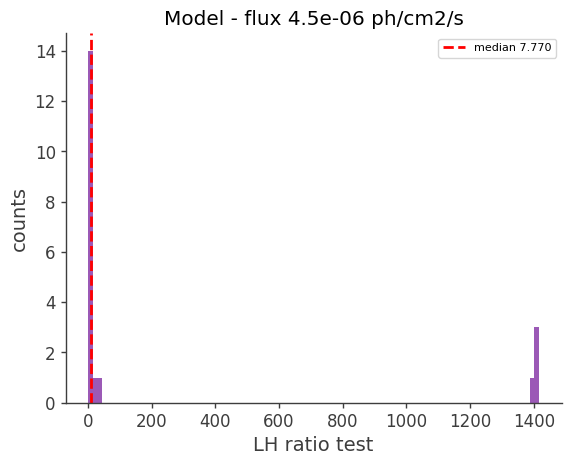

In [18]:
if np.median(LHratiotest) <= 9 :
    print(f"COSI is not sensitive to this model with a flux of {F.value} ph/cm2/s. Please try a higher flux")
else :
    print(f"COSI is 3sigma sensitive to {F.value} ph/cm2/s. You can continue to the next cell")

fig,ax = plt.subplots()
ax.hist(LHratiotest,bins=100)
ax.axvline(np.median(LHratiotest),label=f"median {np.median(LHratiotest):.3f}",color="r",linestyle="--")
ax.legend()
ax.set_xlabel("LH ratio test")
ax.set_ylabel("counts")
ax.set_title(f"Model - flux {F.value} ph/cm2/s")

## Extrapolate the sensitivity to 2 years

DC4 simulations only includes 3 months of orbit. To get the sensitivity after 2 years (nominal life time of COSI) as a first approximation we can scale the flux by $\frac{1}{\sqrt{T}}$    

In [39]:
# 3 * 8 = 24 months = 2 years 

sensi_2y = F/np.sqrt(8)

print(f"3sigma sensitivity after 2 years of COSI observation : {sensi_2y}")


3sigma sensitivity after 2 years of COSI observation : 1.0606601717798212e-05 1 / (s cm2)
